# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

Answer

**What can be said about the three outliers in the upper left corner of the graph?Is their first principal component score high or low? What about their second principal component score?**
X-axis is PC1, Y-axis is PC3 and the three outliers are in the upper(high value of the vertical axis) left(low value on the horizontal axis) corner, so it indicates that outliers have low first principal component score and high second principal component score.

**What does that mean about their values in series_1, series_2, and series_3?**
In PC1 vector, series_3 dominates so low first pricipal component indicates low values specially for series_3. In PC2 vector series_1 and series_2 reflect positive contribution but series_3 has negative coefficient. Hence high second principal component indicates high values for series_1 and series_2 but low value for series_3.

**It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2. Why is that?**

Since both PC1(positive weight) and PC2(negative weight) suggest that series_3 is unusually low for those outliers, it is easier to predict the values. But both series_1 and series_2 contribute positively in PC1 and PC2 and their coefficients are very close. Series_1 and series_2 are highly correlated and PCA indicates that the move to the same direction. PC1 and PC2 are showing series_1 and series_2 together and not encoding series_1>series_2 or series_2>series_1. The individual identities of series_1 and series_2 get blurred. Hence it is hard and almost impossible predict the values of series_1 and series_2.

**How are series_1 and series_2 related, according to how they were created?**

Based on PC1 and PC2 vectors' coefficient series_1 and series_2 are positivity correlated.

**Overall, what are the advantages and disadvantages of the graph below? Does it show anything interesting?**

**Advantages:** The scatter plot of PC1 and PC2 shows 2D summary of series_1,series_2 and series_3. Based on explained_variance_ratio PC1 ~80% and PC2 ~19% so we seeing ~99% of the total variance. It is good for dimensionality reduction. The outliers(on the upper-left) can be easily spotted which will help in anomaly ditection. It reveals relations between variables and shows PC2 separates points where series_3 behaves differently compared to series_1 and series_2. **Disadvantages:** Axes are not intuitive. Without loadings and context the plot is hard to explain to non-technical audiences. Correlated variables series_1 and series_2 are are almost indistinguishable. Actual direct variables values are not available and it makes interpretation less transparent. **Interesting insights:** Upper-left outliers shows cases where series_3 is unusually low compared to the others. Most points lie in a compact structure indicating al three series mostly move together.


[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

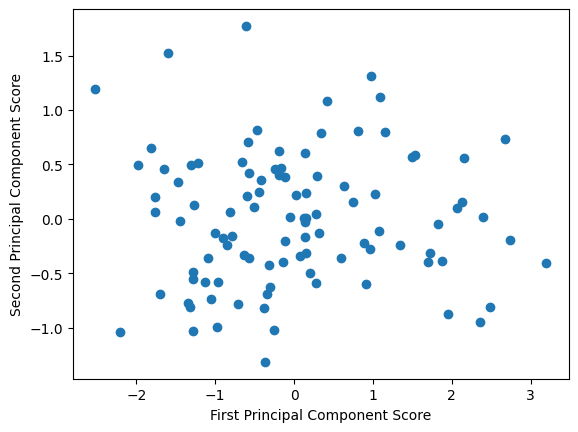

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [8]:
import numpy as np
import seaborn as sns
import pandas as pd
datasource= "http://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42)

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


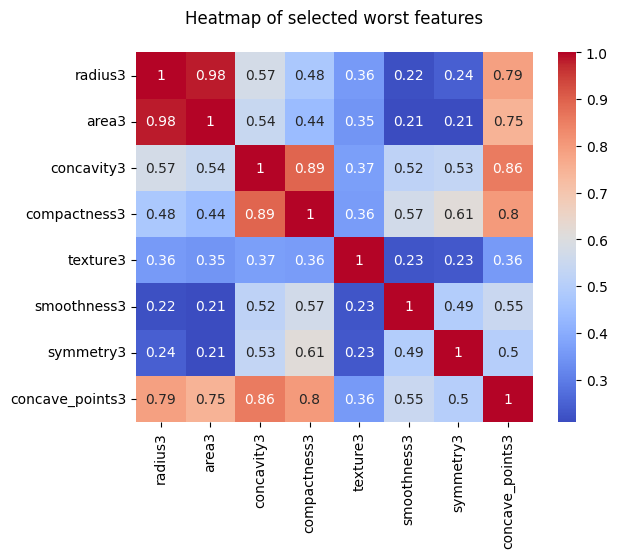

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

#Draw heatmaps
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

df_BreastCancer_3=df_BreastCancer[["radius3","area3","concavity3","compactness3","texture3","smoothness3","symmetry3","concave_points3"]]

#corr=df_BreastCancer_3.corr()["Diagnosis"].abs().sort_values(ascending = False)
sns.heatmap(df_BreastCancer_3.corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap of selected worst features\n")
plt.show()




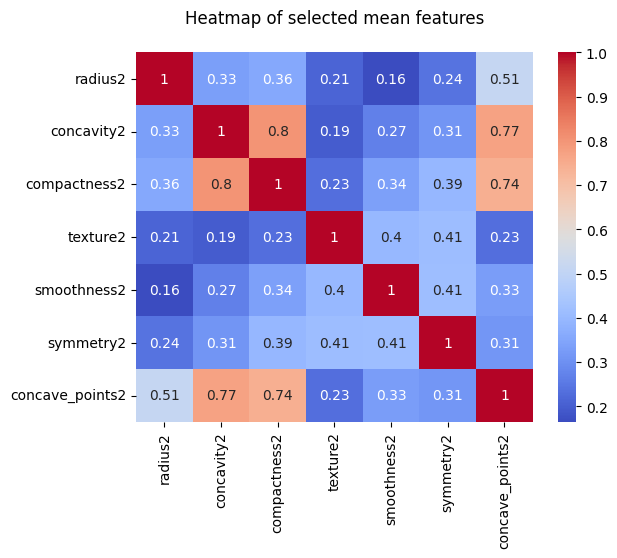

In [4]:
#Draw heatmaps
df_BreastCancer_2=df_BreastCancer[["radius2","concavity2","compactness2","texture2","smoothness2","symmetry2","concave_points2"]]

#corr=df_BreastCancer_3.corr()["Diagnosis"].abs().sort_values(ascending = False)
sns.heatmap(df_BreastCancer_2.corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap of selected mean features\n")
plt.show()


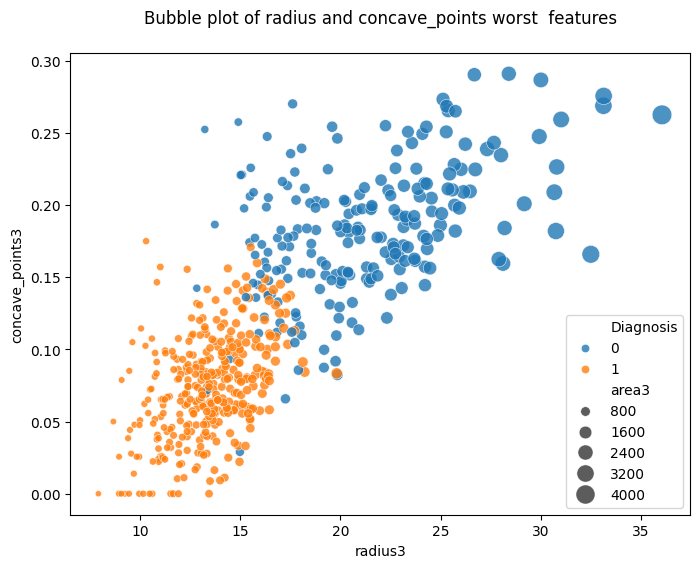

In [5]:
#Draw bubble plots
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_BreastCancer, x="radius3", y="concave_points3", size="area3", hue="Diagnosis", sizes=(20,200), alpha=0.8)
plt.title("Bubble plot of radius and concave_points worst  features\n")
plt.show()


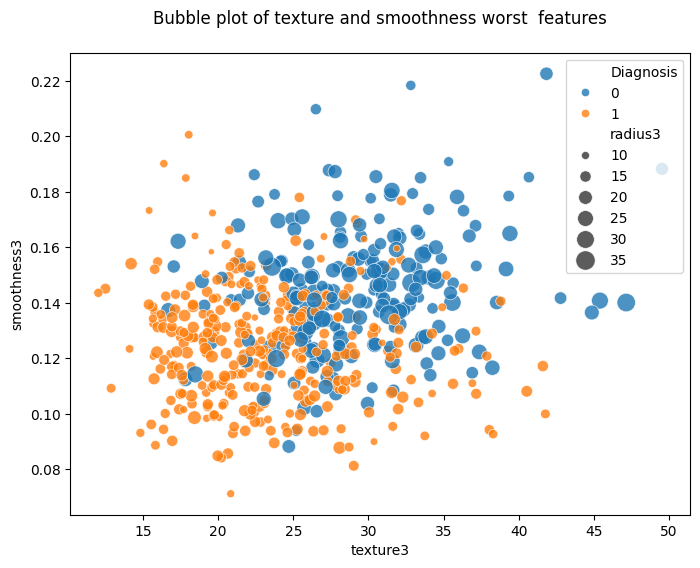

In [6]:
#Draw bubble plots
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_BreastCancer, x="texture3", y="smoothness3", size="radius3", hue="Diagnosis", sizes=(20,200), alpha=0.8)
plt.title("Bubble plot of texture and smoothness worst  features\n")
plt.show()

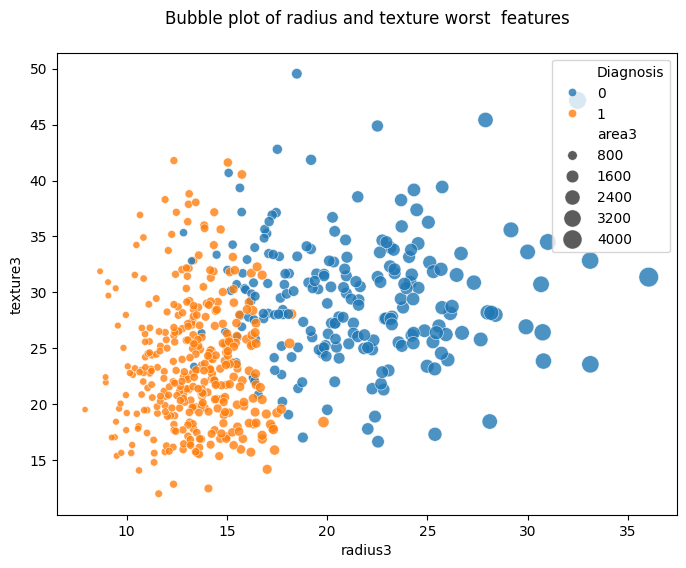

In [7]:
#Draw bubble plots
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_BreastCancer, x="radius3", y="texture3", size="area3", hue="Diagnosis", sizes=(20,200), alpha=0.8)
plt.title("Bubble plot of radius and texture worst  features\n")
plt.show()

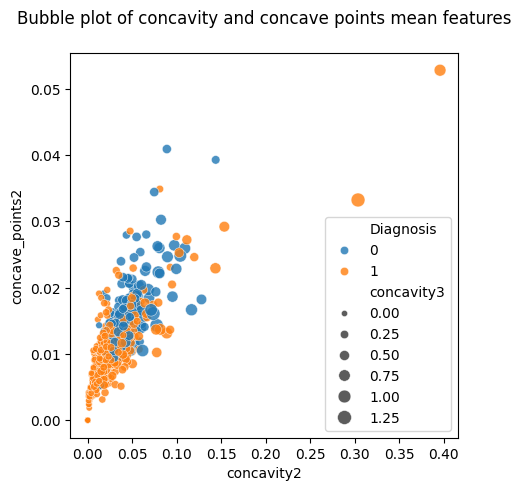

In [8]:
#Draw bubble plots
plt.figure(figsize=(5,5))
sns.scatterplot(data=df_BreastCancer, x="concavity2", y="concave_points2", size="concavity3", hue="Diagnosis", sizes=(20,100), alpha=0.8)
plt.title("Bubble plot of concavity and concave points mean features\n")
plt.show()

[0.44272  0.189712 0.093932]

PC1:  [0.218902 0.103725 0.227537 0.220995 0.14259  0.239285 0.2584   0.260854
 0.138167 0.064363 0.205979 0.017428 0.211326 0.20287  0.014531 0.170393
 0.15359  0.183417 0.042498 0.102568 0.227997 0.104469 0.23664  0.224871
 0.127953 0.210096 0.228768 0.250886 0.122905 0.131784]

PC2:  [-0.233857 -0.059706 -0.215181 -0.231077  0.186113  0.151892  0.060165
 -0.034768  0.190349  0.366575 -0.105552  0.08998  -0.089457 -0.152293
  0.20443   0.232716  0.197207  0.130322  0.183848  0.280092 -0.219866
 -0.045467 -0.199878 -0.219352  0.172304  0.143593  0.097964 -0.008257
  0.141883  0.275339]

PC3:  [-0.008531  0.06455  -0.009314  0.0287   -0.104292 -0.074092  0.002734
 -0.025564 -0.04024  -0.022574  0.268481  0.374634  0.266645  0.216007
  0.308839  0.15478   0.176464  0.224658  0.288584  0.211504 -0.047507
 -0.042298 -0.048547 -0.011902 -0.259798 -0.236076 -0.173057 -0.170344
 -0.271313 -0.232791]


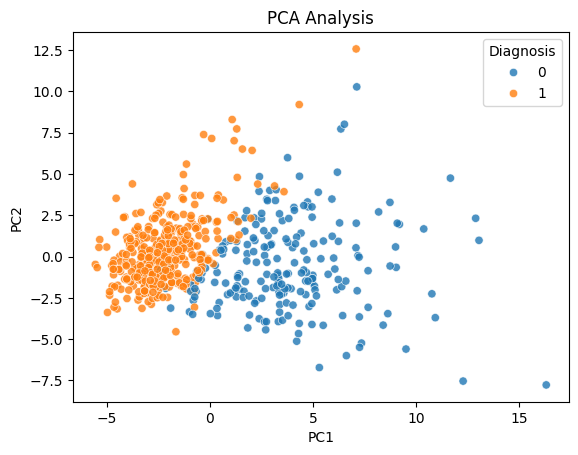

In [5]:
#Principal Component Analysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X=df_BreastCancer.drop(columns=["ID","Diagnosis"])
X_scale= StandardScaler().fit_transform(X)
pca=PCA(n_components = 3)
pca.fit_transform(X_scale)
np.set_printoptions(suppress=True, precision=6)
print(pca.explained_variance_ratio_)
print("\nPC1: ",pca.components_[0])
print("\nPC2: ",pca.components_[1])
print("\nPC3: ",pca.components_[2])

pca2=PCA(n_components = 2)
X_PCA2= pca2.fit_transform(X_scale)
#plot
Y=df_BreastCancer["Diagnosis"]
df_pca= pd.DataFrame(X_PCA2, columns=["PC1","PC2"])
df_pca["Diagnosis"]=Y
#df_pca
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Diagnosis", alpha=0.8)
plt.title("PCA Analysis")
plt.show()



In [7]:
#performing linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
X=df_BreastCancer.drop(columns=["ID","Diagnosis"])
y=df_BreastCancer["Diagnosis"]

model = LinearRegression()
model.fit(X,y)

y_pred= model.predict(X)
print(y_pred[:10])

y_predClass = (y_pred>0.5).astype(int)
accuracy= accuracy_score(y, y_predClass)
print(accuracy)


[-0.045575  0.15787  -0.13132  -0.192288  0.165553  0.301137  0.150293
  0.368009  0.30179  -0.154653]
0.9648506151142355


Conclusions: Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

**Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?**

PC1 is ~44%, PC2 is ~18% and PC3 is ~9%. In PC1 all values are positive with strong weights on radius, area, perimeter and concavity. PC1 interprets overall tumor size/severity. PC1 indicates bigger tumor higher PC1, more irregular(concave) higher PC1. PC2 generates mix of positive and negative values, size related features are negative and texture/surface/irregularity features are positive. It interprets contrast between shape vs texture or smoothness. High PC2 means smoother, more textured tumor; low PC2 means larger bulkier tumor. The Principal Component Analysis suggests that the data can be effectively represented in two dimention using PC1 and PC2 capturing most of the meaningful variations while reducing the complexity.


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.